In [1]:
import pandas as pd

# Load data from csv

health_data = pd.read_csv(r"C:\Users\Gokul Raman\Desktop\Files and Folders\Python Projects\Healthcare project\Health_dataset.csv")

# Display the first few rows

print(health_data.head())

  Patient ID  Gender       Disease         Treatment               Hospital  \
0  PAT-00001    Male  Tuberculosis          Dialysis  City General Hospital   
1  PAT-00002  Female       Malaria          Dialysis  City General Hospital   
2  PAT-00003  Female       Malaria           Surgery  City General Hospital   
3  PAT-00004    Male        Asthma          Dialysis  City General Hospital   
4  PAT-00005  Female      Diabetes  Physical Therapy  City General Hospital   

  Admission Date Discharge Date Treatment Status Cause of Death Date of Birth  
0     2022-12-19     2023-01-16        Recovered            NaN    1973-06-05  
1     2023-03-29     2023-04-21        Recovered            NaN    1998-11-21  
2     2022-09-16     2022-10-15        Recovered            NaN    1942-02-14  
3     2022-02-07     2022-02-11        Recovered            NaN    1943-01-17  
4     2022-10-25     2022-10-30        Recovered            NaN    1979-07-28  


In [2]:
# Count the number of patients

total_records = health_data. shape[0]
print(total_records)

8000


In [3]:
# How is the patient population distributed by gender?

gender_count = health_data['Gender'].value_counts()
print("Gender Distribution:")
print(gender_count)

Gender Distribution:
Gender
Male      5206
Female    2794
Name: count, dtype: int64


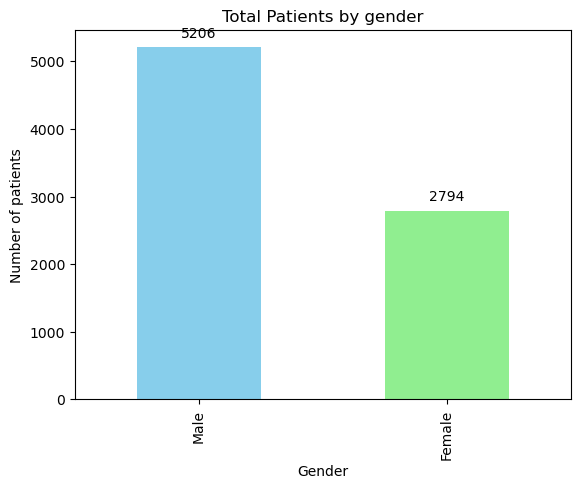

In [4]:
# Visualize gender distribution

import matplotlib.pyplot as plt

ax = gender_count.plot(kind = 'bar', color = ['skyblue', 'lightgreen'])

plt.title("Total Patients by gender")
plt.ylabel("Number of patients")

# Label part
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        int(height),
        xy = (bar.get_x() + bar.get_width()/2, height),
        xytext = (0,5),
        textcoords = "offset points",
        ha = 'center',
        va = 'bottom'
    )
plt.show()

Age Group
21-40     1646
41-60     1608
81-100    1603
61-80     1580
0-20      1533
Name: count, dtype: int64


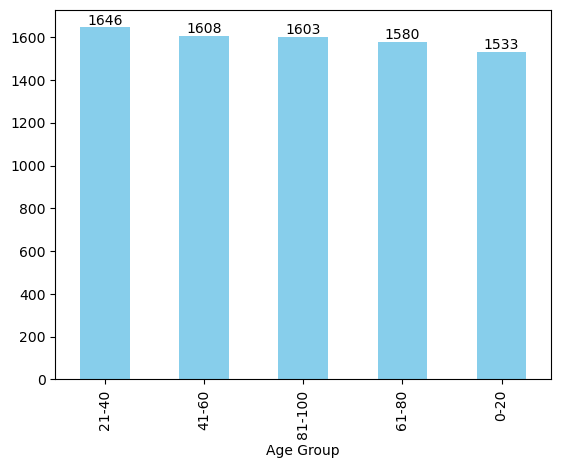

In [5]:
# Patient's Age group by total visit

# Convert the Admission date and Date of Birth to proper date format

health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'])
health_data['Date of Birth'] = pd.to_datetime(health_data['Date of Birth'])

# Calulate the patients age as of the time of Admission in year

health_data['Age'] = (health_data['Admission Date']- health_data['Date of Birth']).dt.days / 365.25
health_data['Age'] = health_data['Age'].astype(int)

### print(health_data["Age"])

# Define Age bins

bins = [0,20,40,60,80,100]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100']

## print(labels)

# Create an age group using the bins var defined

health_data['Age Group'] = pd.cut(health_data['Age'], bins=bins, labels=labels,right=False)

# Count the number of patients in  each group

age_count = health_data['Age Group']. value_counts()

## print(age_count)

# Visualise the age group

ax = age_count.plot(kind = 'bar', color = 'skyblue')

# Add data labels on top of bars
ax.bar_label(ax.containers[0])
print(age_count)

[Text(0, 0, '1193'),
 Text(0, 0, '966'),
 Text(0, 0, '864'),
 Text(0, 0, '694'),
 Text(0, 0, '691'),
 Text(0, 0, '680'),
 Text(0, 0, '567'),
 Text(0, 0, '493'),
 Text(0, 0, '488'),
 Text(0, 0, '475'),
 Text(0, 0, '246'),
 Text(0, 0, '244'),
 Text(0, 0, '173'),
 Text(0, 0, '157'),
 Text(0, 0, '69')]

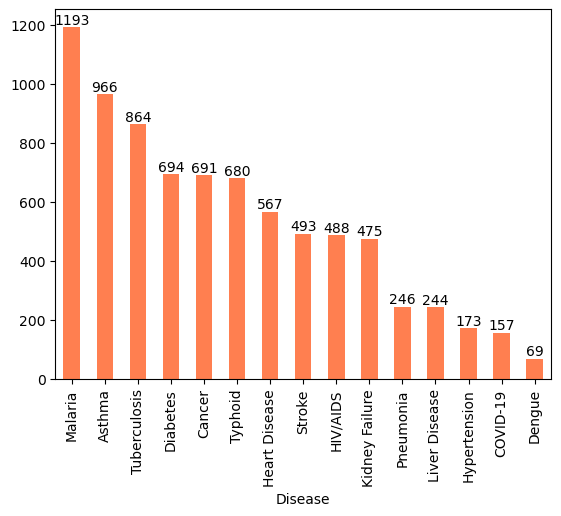

In [6]:
# Which diseases are most commonly diagnosed among the patients
disease_counts = health_data['Disease'].value_counts()
ax = disease_counts.plot(kind = 'bar', color = 'coral')

# Add data labels on top of the bars
ax.bar_label(ax.containers[0])

In [7]:
# Get the top n diseases

dynamic_top = 7
disease_count = health_data['Disease'].value_counts().nlargest(dynamic_top)
#print(disease_count)

total_top = disease_count.sum()
format_value = "{:,}".format(total_top)
description = f"Total count of the {dynamic_top} most common diseases : "
print(description, format_value)

Total count of the 7 most common diseases :  5,655


In [8]:
# Calculate the top 3 percentage of grand total

disease_counttop3 = health_data['Disease'].value_counts().nlargest(3)
total_diseases_count = health_data['Disease'].value_counts().sum()
# print(total_diseases_count)

percentage = (disease_counttop3/total_diseases_count) * 100

roundpercentage = percentage.round(0).astype(int)

for disease,pct in roundpercentage.items():
    print(f"{disease}: {pct}%")

#print(roundpercentage)

Malaria: 15%
Asthma: 12%
Tuberculosis: 11%


In [9]:
# Calculate the top n percentage of n grand total

disease_counttop3 = health_data['Disease'].value_counts().nlargest(3)
total_diseases_top3count = disease_counttop3.sum()
# print(total_diseases_count)

pcttop3 = (disease_counttop3/total_diseases_top3count) * 100

roundpct = pcttop3.round(0).astype(int)

for disease,pct in roundpct.items():
     print(f"{disease}: {pct}%")

Malaria: 39%
Asthma: 32%
Tuberculosis: 29%


In [10]:
# Are certain diseases more prevalent in one gender compared to others

gender_disease = pd.crosstab(health_data['Disease'], health_data['Gender'])
print("Diseases that are common among genders")
print(gender_disease)

Diseases that are common among genders
Gender          Female  Male
Disease                     
Asthma             320   646
COVID-19            53   104
Cancer             239   452
Dengue              27    42
Diabetes           256   438
HIV/AIDS           155   333
Heart Disease      206   361
Hypertension        65   108
Kidney Failure     182   293
Liver Disease       73   171
Malaria            407   786
Pneumonia           93   153
Stroke             177   316
Tuberculosis       302   562
Typhoid            239   441


In [11]:
# Calculate the duration of each patient stay and create a group to show number of patients in each group

# convert date to proper data type

health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'])
health_data['Discharge Date'] = pd.to_datetime(health_data['Discharge Date'])

health_data['Stay Duration'] = (health_data['Discharge Date'] - health_data['Admission Date']).dt.days

print(health_data[['Admission Date','Discharge Date','Stay Duration']].head(20))

   Admission Date Discharge Date  Stay Duration
0      2022-12-19     2023-01-16             28
1      2023-03-29     2023-04-21             23
2      2022-09-16     2022-10-15             29
3      2022-02-07     2022-02-11              4
4      2022-10-25     2022-10-30              5
5      2022-02-07     2022-02-15              8
6      2022-06-07     2022-06-30             23
7      2022-06-26     2022-06-27              1
8      2023-07-21     2023-08-07             17
9      2023-12-25     2024-01-05             11
10     2023-01-15     2023-02-05             21
11     2022-08-31     2022-09-12             12
12     2022-01-12     2022-02-03             22
13     2022-04-10     2022-04-20             10
14     2023-07-01     2023-07-19             18
15     2022-02-04     2022-02-24             20
16     2023-06-28     2023-07-05              7
17     2022-11-03     2022-11-29             26
18     2023-07-01     2023-07-08              7
19     2022-04-05     2022-04-09        

In [12]:
# Group Saty Duration

bins = [-1,0,3,7,14,float('inf')]
labels = ["Same Day","1-3 Days","4-7 Days","8-14 Days", "Above 21 Days"]

health_data['Stay Bucket'] = pd.cut(health_data['Stay Duration'], bins=bins, labels=labels, right = True)
print (health_data['Stay Bucket'])

0       Above 21 Days
1       Above 21 Days
2       Above 21 Days
3            4-7 Days
4            4-7 Days
            ...      
7995         4-7 Days
7996    Above 21 Days
7997        8-14 Days
7998    Above 21 Days
7999    Above 21 Days
Name: Stay Bucket, Length: 8000, dtype: category
Categories (5, object): ['Same Day' < '1-3 Days' < '4-7 Days' < '8-14 Days' < 'Above 21 Days']


In [13]:
# number of patient on each group

total_group_patient = health_data['Stay Bucket']. value_counts()
print(total_group_patient)

Stay Bucket
Above 21 Days    4269
8-14 Days        1837
4-7 Days         1087
1-3 Days          807
Same Day            0
Name: count, dtype: int64


[Text(0, 0, '4269'),
 Text(0, 0, '1837'),
 Text(0, 0, '1087'),
 Text(0, 0, '807'),
 Text(0, 0, '0')]

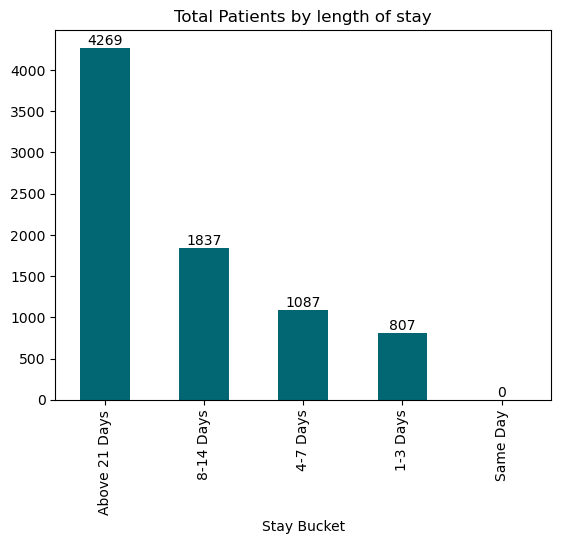

In [33]:
# Create chart to display no. of patients for each group

ax = total_group_patient.plot(kind = 'bar', color = ['#026773'])
plt.title("Total Patients by length of stay")

# Add data labels on top of the bars
ax.bar_label(ax.containers[0])

In [15]:
# For any records with a recorded course of death, analyze pattern to identify risk factor

# Filter records where the cause of death is not empty

death_cause = health_data.dropna(subset = 'Cause of Death')
count_cause = death_cause['Cause of Death'].value_counts()

print("Most common cause of Death")
print(count_cause)

Most common cause of Death
Cause of Death
Multiple Organ Failure    114
Respiratory Failure       109
Cardiac Arrest            102
Septic Shock               94
Name: count, dtype: int64


[Text(0, 0, '114'), Text(0, 0, '109'), Text(0, 0, '102'), Text(0, 0, '94')]

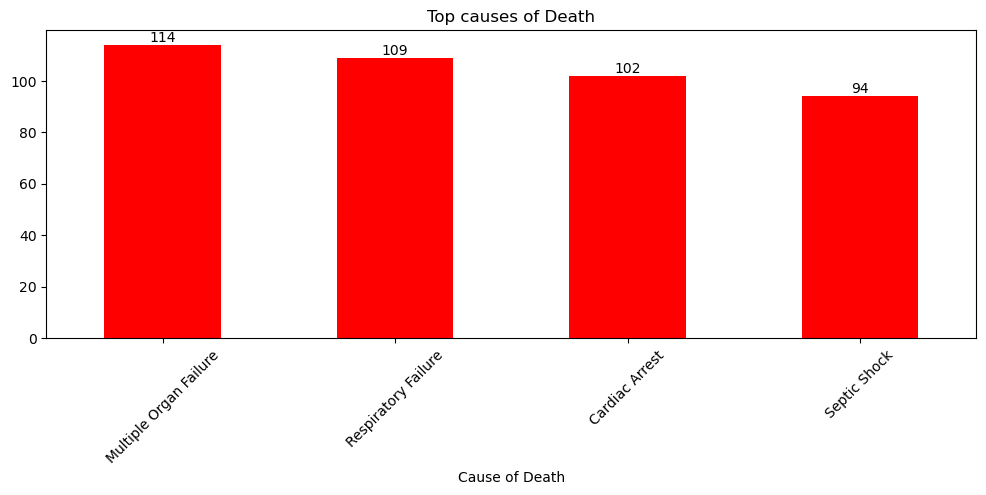

In [34]:
# Create chart to display common cause of death

plt.figure(figsize = (12,4))
ax = count_cause.plot(kind = 'bar', color = 'red')
plt.xticks(rotation = 45)
plt.title("Top causes of Death")

# Add data labels on top of the bars
ax.bar_label(ax.containers[0])

In [17]:
# What are the percentage of patients : Deceased, Under-treatment and Recovered patients

total_patients = health_data.shape[0]
total_patients

8000

In [18]:
# Total death patients

total_death = (health_data['Treatment Status'].str.lower() == 'deceased').sum()
total_death

419

In [19]:
# prercentage of deceased

death_rate = (total_death / total_patients)*100 if total_patients > 0 else 0
death_rate

5.2375

In [20]:
print(f"Total patients", total_patients)
print(f"Total Casualities", total_death)
print(f"Casuality Rate", death_rate)

Total patients 8000
Total Casualities 419
Casuality Rate 5.2375


In [21]:
# Recovered patients

total_recovered = (health_data['Treatment Status'].str.lower() == 'recovered').sum()

# prercentage of recovered
recovered_rate = (total_recovered / total_patients)*100 if total_patients > 0 else 0
recovered_rate

85.2375

In [22]:
# Under Treatment patients

under_treatment = 100 - (recovered_rate + death_rate)
under_treatment

9.525000000000006

In [23]:
# Show this as donut chart

print (f"Total recovery Rate:", recovered_rate)
print(f"Casuality Rate", death_rate)
print(f"Under treatment Rate:", under_treatment)

Total recovery Rate: 85.2375
Casuality Rate 5.2375
Under treatment Rate: 9.525000000000006


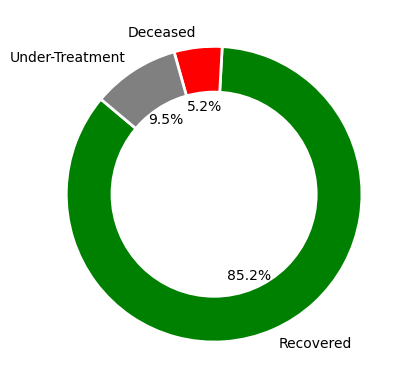

In [24]:
labels = ['Recovered', 'Deceased', 'Under-Treatment']
sizes = [recovered_rate, death_rate, under_treatment]
colors = ['green', 'red', 'gray']

plt.Figure(figsize = (12,8))
plt.pie(sizes,labels = labels, autopct = '%1.1f%%',
       colors = colors, startangle = 140, wedgeprops = {'edgecolor': 'white','linewidth':2})
plt.gca().add_artist(plt.Circle((0,0),0.70, fc = 'white'))

plt.show()

In [25]:
import seaborn as sns

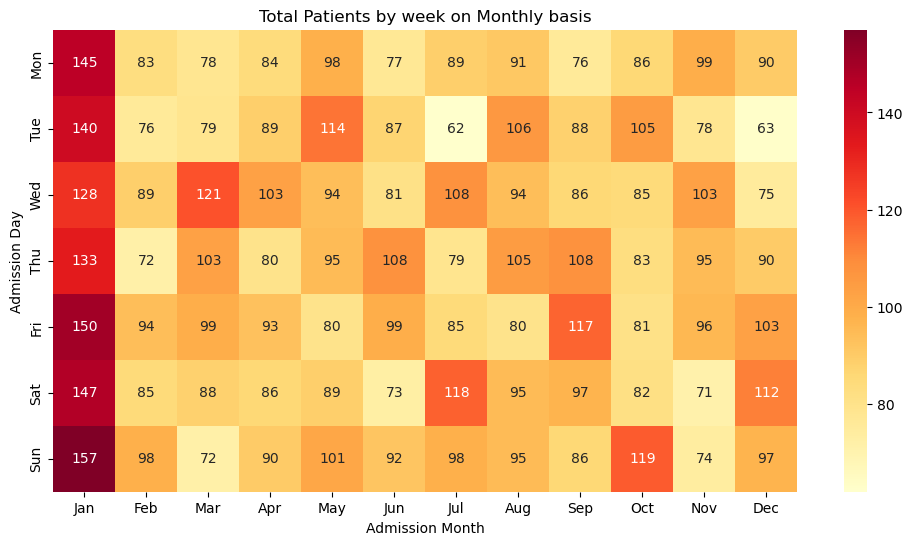

In [26]:
# What are the peak days of the week on a monthly besis for admissions and discharges?

# Convert Admission date column to proper date format

health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'],errors = "coerce")

# Extract the short day and month name

health_data['Admission Month'] = health_data['Admission Date'].dt.strftime('%b')
health_data['Admission Day'] = health_data['Admission Date'].dt.strftime('%a')

# Define the order for generated month and days

month_order = [
    'Jan', 'Feb','Mar','Apr','May', 'Jun',
    'Jul','Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# Create a Pivot Table

admission_heatmap = health_data.pivot_table(
    index = 'Admission Day',
    columns = 'Admission Month',
    aggfunc = 'size',
    fill_value = 0
)

# Correct order of heatmap data

admission_heatmap_sorted = admission_heatmap.reindex(index = day_order, columns = month_order )

# admission_heatmap_sorted

# Plot the heatmap

plt.figure(figsize = (12, 6))
sns.heatmap(admission_heatmap_sorted, annot=True, fmt ="d", cmap= "YlOrRd")
plt.title('Total Patients by week on Monthly basis')
plt.show()

In [27]:
# What is the total no. of patients admitted per week, month and year? Add a filter to filtr the month by Year.

# Create a new column
health_data['Admission Day'] = health_data['Admission Date'].dt.strftime('%a')

# health_data

# Group data by day name and count admission
admission_by_day = health_data.groupby("Admission Day").size()

# Sort the name of day
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
admission_by_day = admission_by_day.reindex(day_order, fill_value = 0)
admission_by_day

Admission Day
Mon    1096
Tue    1087
Wed    1167
Thu    1151
Fri    1177
Sat    1143
Sun    1179
dtype: int64

Admission Day
Mon    1096
Tue    1087
Wed    1167
Thu    1151
Fri    1177
Sat    1143
Sun    1179
dtype: int64

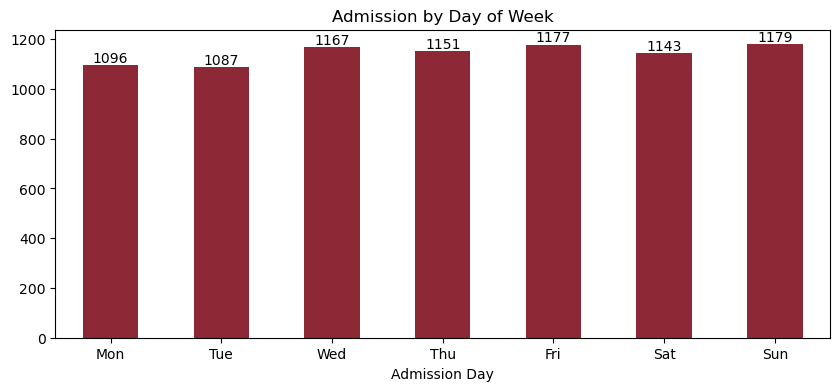

In [35]:
# Create a visual

ax = admission_by_day.plot(kind = "bar", color = "#8D2837", figsize = (10,4))
plt.title('Admission by Day of Week')
plt.xticks(rotation = 0)

# Add data labels on top of the bars
ax.bar_label(ax.containers[0])
admission_by_day

In [29]:
# Find Top 3 days with high admission

top_3_admission_day = health_data['Admission Day'].value_counts().nlargest(3)
top_3_admission_day

Admission Day
Sun    1179
Fri    1177
Wed    1167
Name: count, dtype: int64

In [30]:
# Find Bottom 3 days with high admission

bot_3_admission_day = health_data['Admission Day'].value_counts().nsmallest(3)
bot_3_admission_day

Admission Day
Tue    1087
Mon    1096
Sat    1143
Name: count, dtype: int64

In [31]:
# Find total admission by month filtered by year

# Filter using year of admission

selected_year = 2022
health_data_year = health_data[health_data['Admission Date'].dt.year == selected_year].copy()


# Adding the month column

health_data_year['Admission Month'] = health_data_year['Admission Date'].dt.month

# Extracting Month Name

health_data_year['Month Name'] = health_data_year['Admission Date'].dt.month_name()

# Total Admission on a monthly basis

monthly_admission =(
    health_data_year
    .groupby(['Admission Month','Month Name'])
    .size()
    .reset_index(name='Total Patients')
    .sort_values('Admission Month')
    )
print(f"Total Patients admitted in the year {selected_year}")
monthly_admission

Total Patients admitted in the year 2022


,Admission Month,Month Name,Total Patients
0,1,January,351
1,2,February,291
2,3,March,313
3,4,April,327
4,5,May,349
5,6,June,315
6,7,July,327
7,8,August,329
8,9,September,311
9,10,October,311


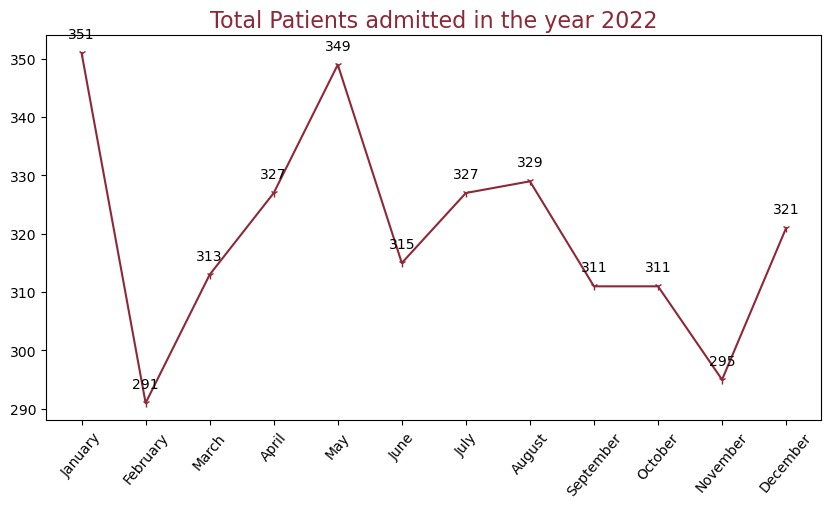

In [36]:
# Create a line chart to visualise

# Setting figure size
plt.figure(figsize = (10,5))

# Plotting the data
plt.plot(monthly_admission['Month Name'], monthly_admission['Total Patients'],
        marker = '1', linestyle = '-', color = '#8D2837'
        )

# Add data labels to the line chart
for x, y in zip(monthly_admission['Month Name'], monthly_admission['Total Patients']):
    # The 'y + 2' adds a little vertical space so the text doesn't overlap the line
    plt.text(x, y + 2, str(y), ha='center', va='bottom')


    plt.title(f"Total Patients admitted in the year {selected_year}",
         fontsize = 16, color = '#8D2837')

plt.xticks(rotation = 50)
plt.show()